# Credit Risk Prediction — Give Me Some Credit (Kaggle)

**Author:** Leila Rezaei
**Objective:** Predict the probability that a borrower will experience serious financial
distress (90+ days delinquent) within the next two years, using real historical
credit-bureau-style data.

**Data source:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit/data) (Kaggle competition dataset).
Download `cs-training.csv` and place it in `data/raw/`.

**Target variable:** `SeriousDlqin2yrs` (1 = borrower experienced 90+ days delinquency, 0 = did not)

This is framed correctly as a **binary classification problem** (credit risk scoring),
not a time-series forecasting problem — the dataset is cross-sectional, one row per borrower.


## 1. Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load Data

Two options — use whichever works for you:

**Option A (easiest, no Kaggle account needed):** the notebook downloads the CSV directly
from a public GitHub mirror of the same Kaggle dataset.

**Option B:** if you already have `cs-training.csv` saved locally (e.g. downloaded from
Kaggle yourself), put it in `data/raw/` and the notebook will use that instead.

In [7]:
import os

local_path = "cs-training.csv"
mirror_url = ("https://raw.githubusercontent.com/JLZml/Credit-Scoring-Data-Sets/"
              "master/3.%20Kaggle/Give%20Me%20Some%20Credit/cs-training.csv")

if os.path.exists(local_path):
    df = pd.read_csv(local_path, index_col=0)
    print("Loaded local file:", local_path)
else:
    df = pd.read_csv(mirror_url, index_col=0)
    print("Loaded from GitHub mirror:", mirror_url)
    df.to_csv(local_path)

print(df.shape)
df.head()

Loaded local file: cs-training.csv
(150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Exploratory Data Analysis

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [10]:
# Missing values
df.isnull().sum().sort_values(ascending=False)


,0
MonthlyIncome,29731
NumberOfDependents,3924
SeriousDlqin2yrs,0
age,0
RevolvingUtilizationOfUnsecuredLines,0
DebtRatio,0
NumberOfTime30-59DaysPastDueNotWorse,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


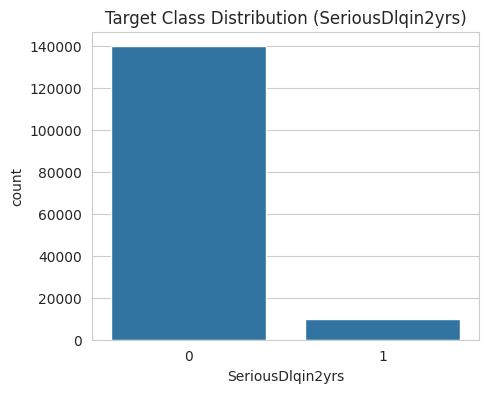

In [11]:
# Target class balance
target_counts = df["SeriousDlqin2yrs"].value_counts(normalize=True)
print(target_counts)

plt.figure(figsize=(5,4))
sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Target Class Distribution (SeriousDlqin2yrs)")
plt.show()


**Note:** This dataset is known to be highly imbalanced (~6-7% positive class).
This needs to be addressed explicitly in evaluation — accuracy alone is misleading;
precision, recall, F1, and ROC-AUC matter more here.

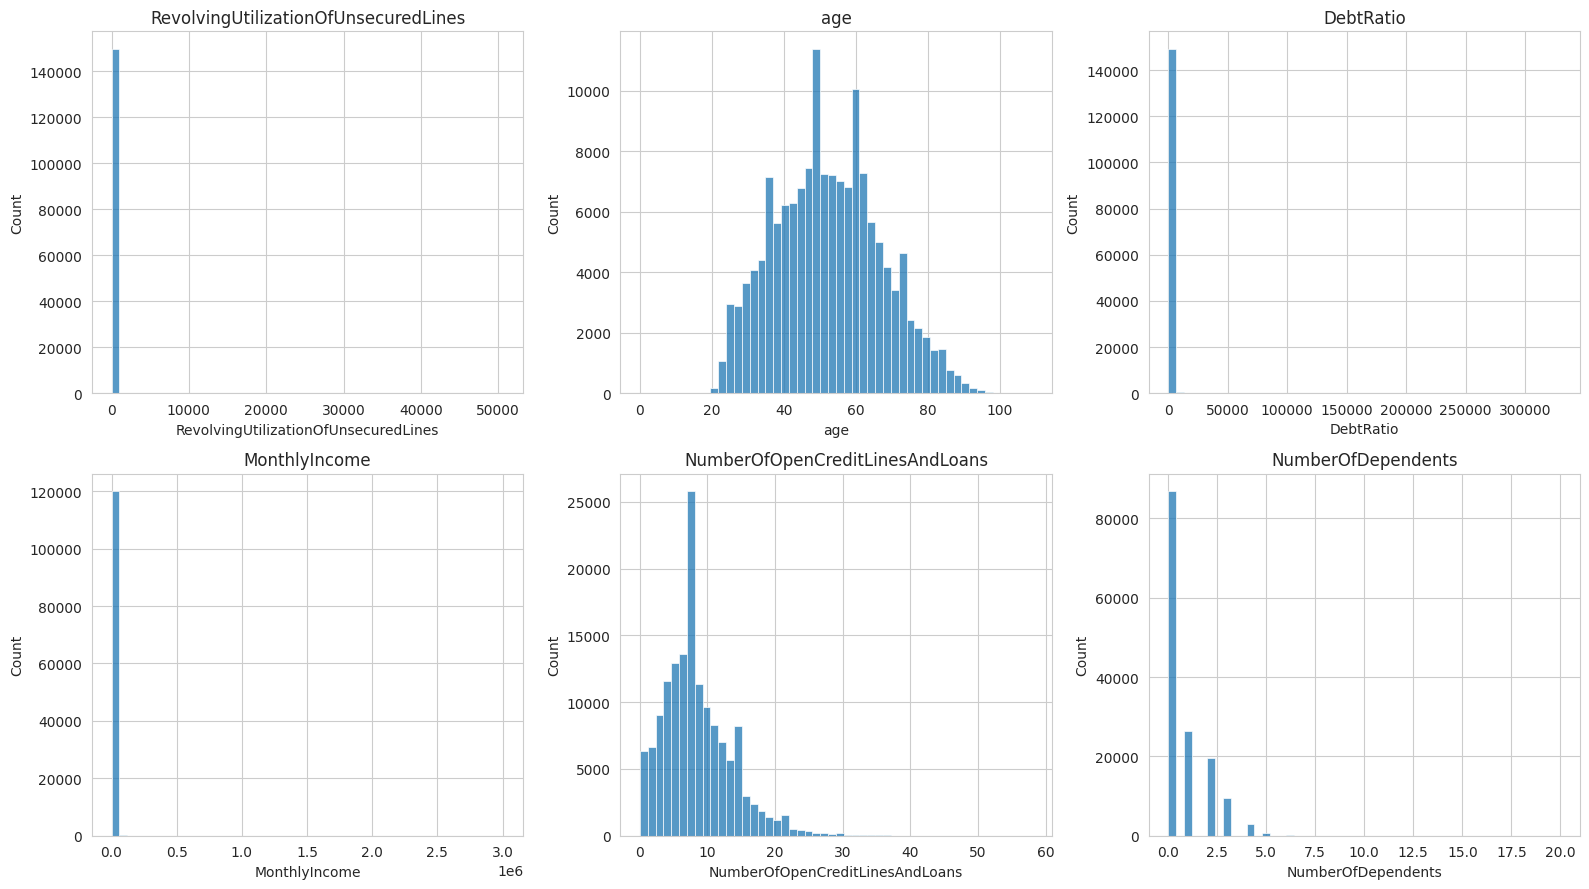

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio",
            "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans", "NumberOfDependents"]
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Data Cleaning

Handle missing values and known extreme outliers (documented in the Kaggle discussion for this dataset).

In [13]:
df_clean = df.copy()

# MonthlyIncome: impute missing with median (heavily skewed)
df_clean["MonthlyIncome"] = df_clean["MonthlyIncome"].fillna(df_clean["MonthlyIncome"].median())

# NumberOfDependents: impute missing with mode (usually 0)
df_clean["NumberOfDependents"] = df_clean["NumberOfDependents"].fillna(df_clean["NumberOfDependents"].mode()[0])

# age: a small number of rows have age == 0, which is invalid; drop them
df_clean = df_clean[df_clean["age"] > 0]

# RevolvingUtilizationOfUnsecuredLines and DebtRatio: cap extreme outliers at the 99th percentile
for col in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = np.where(df_clean[col] > cap, cap, df_clean[col])

# Late-payment count columns sometimes contain sentinel values (96, 98) — cap at 90th percentile+1
late_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
             "NumberOfTime60-89DaysPastDueNotWorse",
             "NumberOfTimes90DaysLate"]
for col in late_cols:
    cap = df_clean[col].quantile(0.99)
    df_clean[col] = np.where(df_clean[col] > cap, cap, df_clean[col])

print("Rows before cleaning:", df.shape[0])
print("Rows after cleaning:", df_clean.shape[0])
df_clean.isnull().sum().sum()


Rows before cleaning: 150000
Rows after cleaning: 149999


np.int64(0)

## 5. Feature Engineering

In [14]:
df_clean["TotalPastDue"] = df_clean[late_cols].sum(axis=1)
df_clean["IncomePerDependent"] = df_clean["MonthlyIncome"] / (df_clean["NumberOfDependents"] + 1)
df_clean["DebtToIncomeProxy"] = df_clean["DebtRatio"] * df_clean["MonthlyIncome"]

df_clean.head()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue,IncomePerDependent,DebtToIncomeProxy
1,1,0.766127,45,2.0,0.802982,9120.0,13,0.0,6,0.0,2.0,2.0,3040.0,7323.197016
2,0,0.957151,40,0.0,0.121876,2600.0,4,0.0,0,0.0,1.0,0.0,1300.0,316.878123
3,0,0.658180,38,1.0,0.085113,3042.0,2,1.0,0,0.0,0.0,2.0,3042.0,258.914887
4,0,0.233810,30,0.0,0.036050,3300.0,5,0.0,0,0.0,0.0,0.0,3300.0,118.963951
5,0,0.907239,49,1.0,0.024926,63588.0,7,0.0,1,0.0,0.0,1.0,63588.0,1584.975094


## 6. Train / Test Split & Scaling

In [15]:
feature_cols = [c for c in df_clean.columns if c != "SeriousDlqin2yrs"]
X = df_clean[feature_cols]
y = df_clean["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)


(119999, 13) (30000, 13)


## 7. Modeling

Two models are trained for comparison:
- **Logistic Regression** — interpretable baseline
- **Random Forest** — captures non-linear interactions, `class_weight="balanced"` to address class imbalance

In [16]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       n_jobs=-1, random_state=42)

## 8. Evaluation

In [17]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1 Score :", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 4))
    print()
    print(classification_report(y_true, y_pred))

log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
evaluate("Logistic Regression", y_test, log_pred, log_proba)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]
evaluate("Random Forest", y_test, rf_pred, rf_proba)


--- Logistic Regression ---
Accuracy : 0.8071
Precision: 0.2216
Recall   : 0.7506
F1 Score : 0.3422
ROC-AUC  : 0.8614

              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.75      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.61     30000
weighted avg       0.93      0.81      0.85     30000

--- Random Forest ---
Accuracy : 0.8354
Precision: 0.2475
Recall   : 0.7167
F1 Score : 0.3679
ROC-AUC  : 0.865

              precision    recall  f1-score   support

           0       0.98      0.84      0.91     27995
           1       0.25      0.72      0.37      2005

    accuracy                           0.84     30000
   macro avg       0.61      0.78      0.64     30000
weighted avg       0.93      0.84      0.87     30000



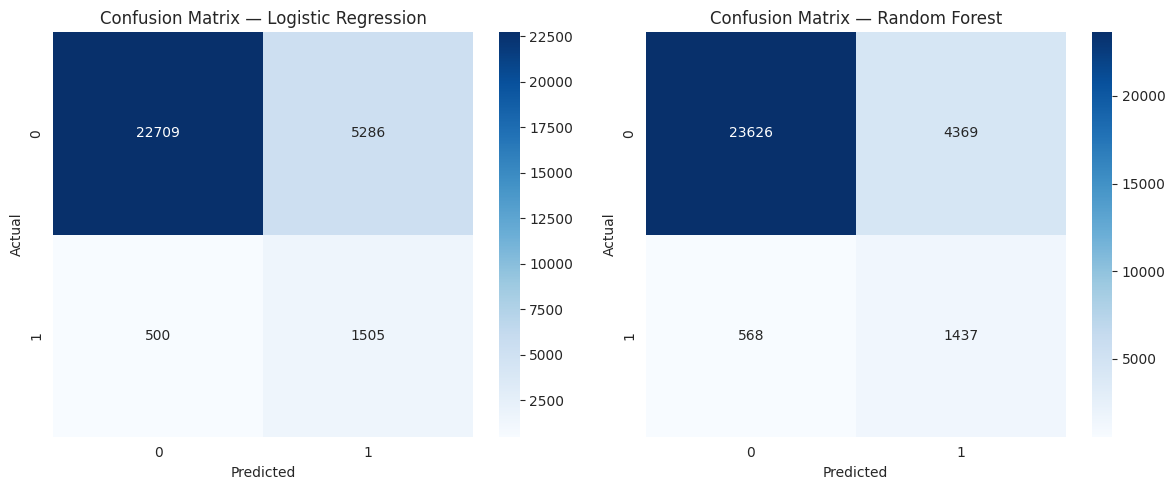

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, pred) in zip(axes, [("Logistic Regression", log_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


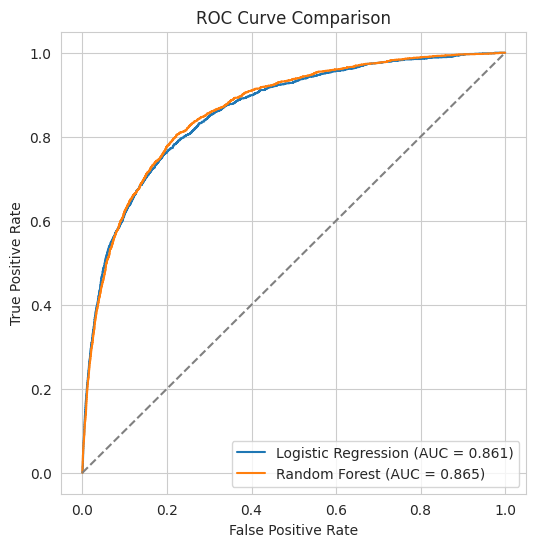

In [19]:
plt.figure(figsize=(6,6))
for name, proba in [("Logistic Regression", log_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## 9. Feature Importance (Random Forest)

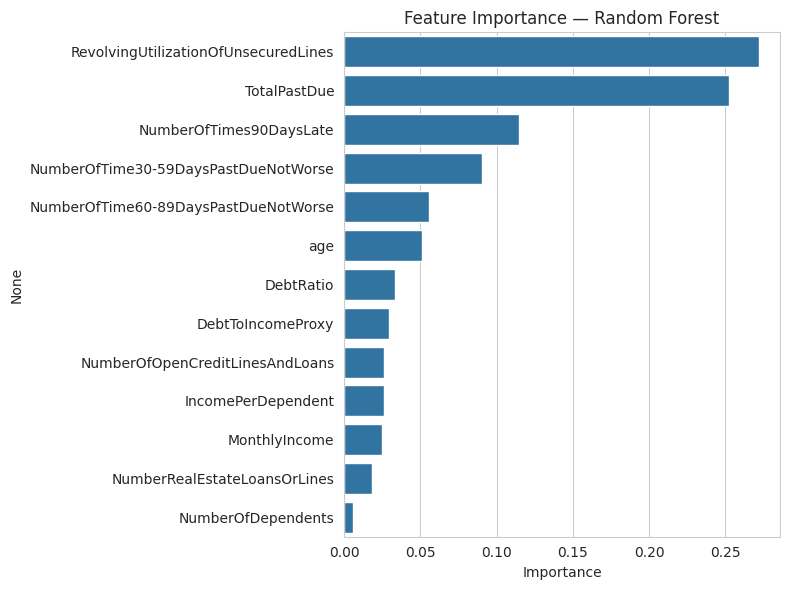

,0
RevolvingUtilizationOfUnsecuredLines,0.272229
TotalPastDue,0.252530
NumberOfTimes90DaysLate,0.114471
NumberOfTime30-59DaysPastDueNotWorse,0.090359
NumberOfTime60-89DaysPastDueNotWorse,0.055576
age,0.050782
DebtRatio,0.033303
DebtToIncomeProxy,0.029660
NumberOfOpenCreditLinesAndLoans,0.026301
IncomePerDependent,0.026088


In [20]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances


## 10. Discussion & Limitations

- The dataset is cross-sectional (one snapshot per borrower), so this is a
  **classification / credit scoring** task, not a time-series forecast.
- Class imbalance (~6-7% positive) means accuracy alone is not a reliable metric;
  precision, recall, and ROC-AUC were prioritized.
- Outlier capping (winsorizing at the 99th percentile) was applied to known problematic
  columns (`RevolvingUtilizationOfUnsecuredLines`, `DebtRatio`, late-payment counts) based on
  documented data quality issues in this dataset.
- Results should be interpreted as a demonstration of methodology, not as a
  production-ready credit scoring model — real deployment would require regulatory
  compliance checks (e.g., fair lending / disparate impact analysis), which are out of scope here.

## 11. Next Steps
- Try gradient boosting models (XGBoost / LightGBM) for comparison.
- Use SMOTE or other resampling techniques as an alternative to `class_weight="balanced"`.
- Perform hyperparameter tuning with cross-validation (GridSearchCV / Optuna).
- Calibrate predicted probabilities (Platt scaling / isotonic regression) if the model is
  meant to output usable risk scores.
